In [1]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv('../data/all_reviews.csv')

# Đếm số lượng rating của từng sản phẩm
product_counts = df['id_product'].value_counts()

# Chọn các sản phẩm có từ 10 rating trở lên
popular_products = product_counts[product_counts >= 10].index.tolist()

print(f'Số lượng sản phẩm thỏa mãn: {len(popular_products)}')


Số lượng sản phẩm thỏa mãn: 965


In [2]:
# Lọc dữ liệu cho các sản phẩm thỏa mãn
filtered_df = df[df['id_product'].isin(popular_products)]

print(f'Số lượng dòng dữ liệu sau lọc: {filtered_df.shape[0]}')

Số lượng dòng dữ liệu sau lọc: 34102


In [ ]:
# Tạo tập testing: với mỗi sản phẩm, lấy ngẫu nhiên 3 dòng
testing_df = filtered_df.groupby('id_product').sample(n=3, random_state=42)

# Tạo tập training bằng cách loại bỏ các dòng trong tập testing khỏi filtered_df
training_df = pd.concat([filtered_df, testing_df]).drop_duplicates(keep=False)

# Kiểm tra số lượng
print(f'Số lượng dòng tập testing: {testing_df.shape[0]}')
print(f'Số lượng dòng tập training: {training_df.shape[0]}')

Số lượng dòng tập testing: 2895
Số lượng dòng tập training: 25262


In [4]:
# Nếu số lượng dòng tập testing lớn hơn 500 thì lấy ngẫu nhiên 500 dòng
if testing_df.shape[0] > 500:
    testing_df_sampled = testing_df.sample(n=500, random_state=42)
else:
    testing_df_sampled = testing_df

# Kiểm tra số lượng
print(f'Số lượng dòng tập testing được chọn để đánh giá: {testing_df_sampled.shape[0]}')

Số lượng dòng tập testing được chọn để đánh giá: 500


In [5]:
testing_df_sampled.to_csv('../data/collabrative/item_based_testing_set.csv', index=False)
training_df.to_csv('../data/collabrative/item_based_training_set.csv', index=False)

BƯỚC 1: HUẤN LUYỆN MÔ HÌNH COSINE SIMILARITY
Đang xây dựng mô hình với cosine similarity...
Kích thước ma trận user-item: (15494, 936)
Đang tính toán ma trận tương đồng cosine...
Hoàn thành! Ma trận tương đồng có kích thước: (936, 936)

BƯỚC 2: HUẤN LUYỆN MÔ HÌNH PEARSON SIMILARITY
Đang xây dựng mô hình với pearson similarity...
Kích thước ma trận user-item: (15494, 936)
Đang tính toán ma trận tương đồng pearson...
Đang tính Pearson similarity...
Đã xử lý: 0/936 items (0.0%)
Đã xử lý: 50/936 items (5.3%)
Đã xử lý: 100/936 items (10.7%)
Đã xử lý: 150/936 items (16.0%)
Đã xử lý: 200/936 items (21.4%)
Đã xử lý: 250/936 items (26.7%)
Đã xử lý: 300/936 items (32.1%)
Đã xử lý: 350/936 items (37.4%)
Đã xử lý: 400/936 items (42.7%)
Đã xử lý: 450/936 items (48.1%)
Đã xử lý: 500/936 items (53.4%)
Đã xử lý: 550/936 items (58.8%)
Đã xử lý: 600/936 items (64.1%)
Đã xử lý: 650/936 items (69.4%)
Đã xử lý: 700/936 items (74.8%)
Đã xử lý: 750/936 items (80.1%)
Đã xử lý: 800/936 items (85.5%)
Đã xử lý: 

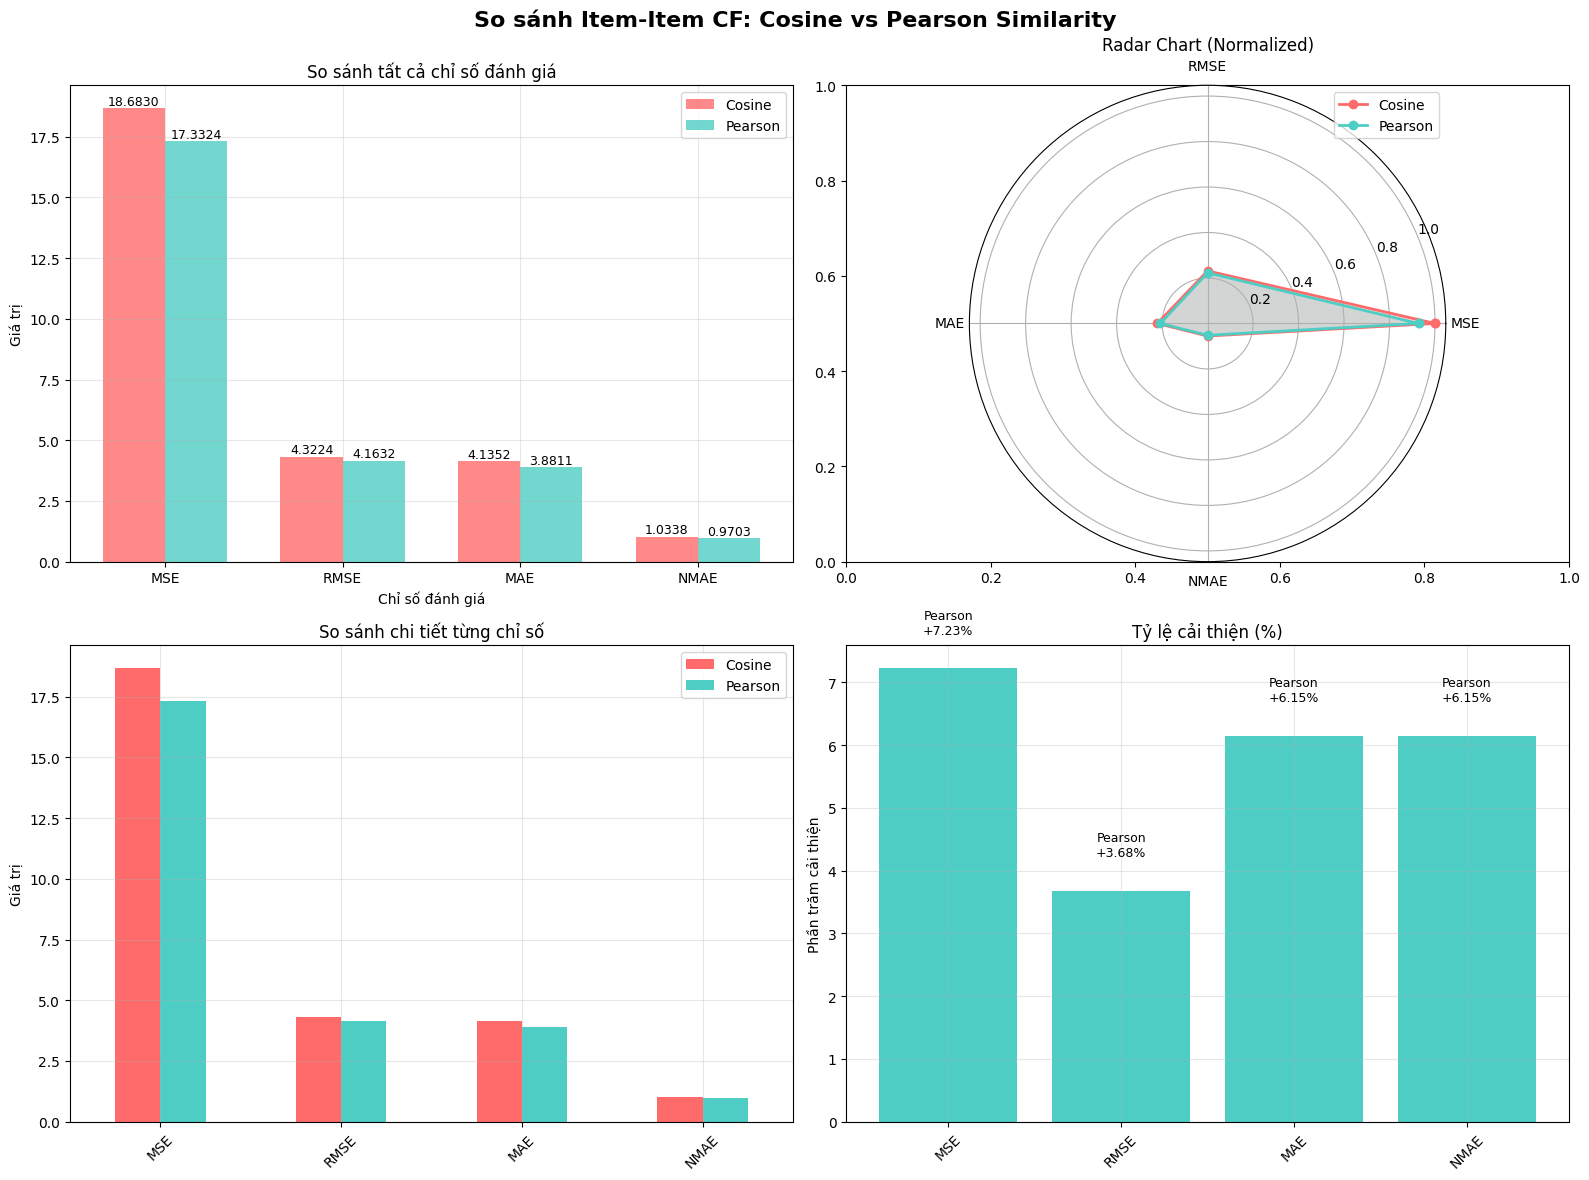

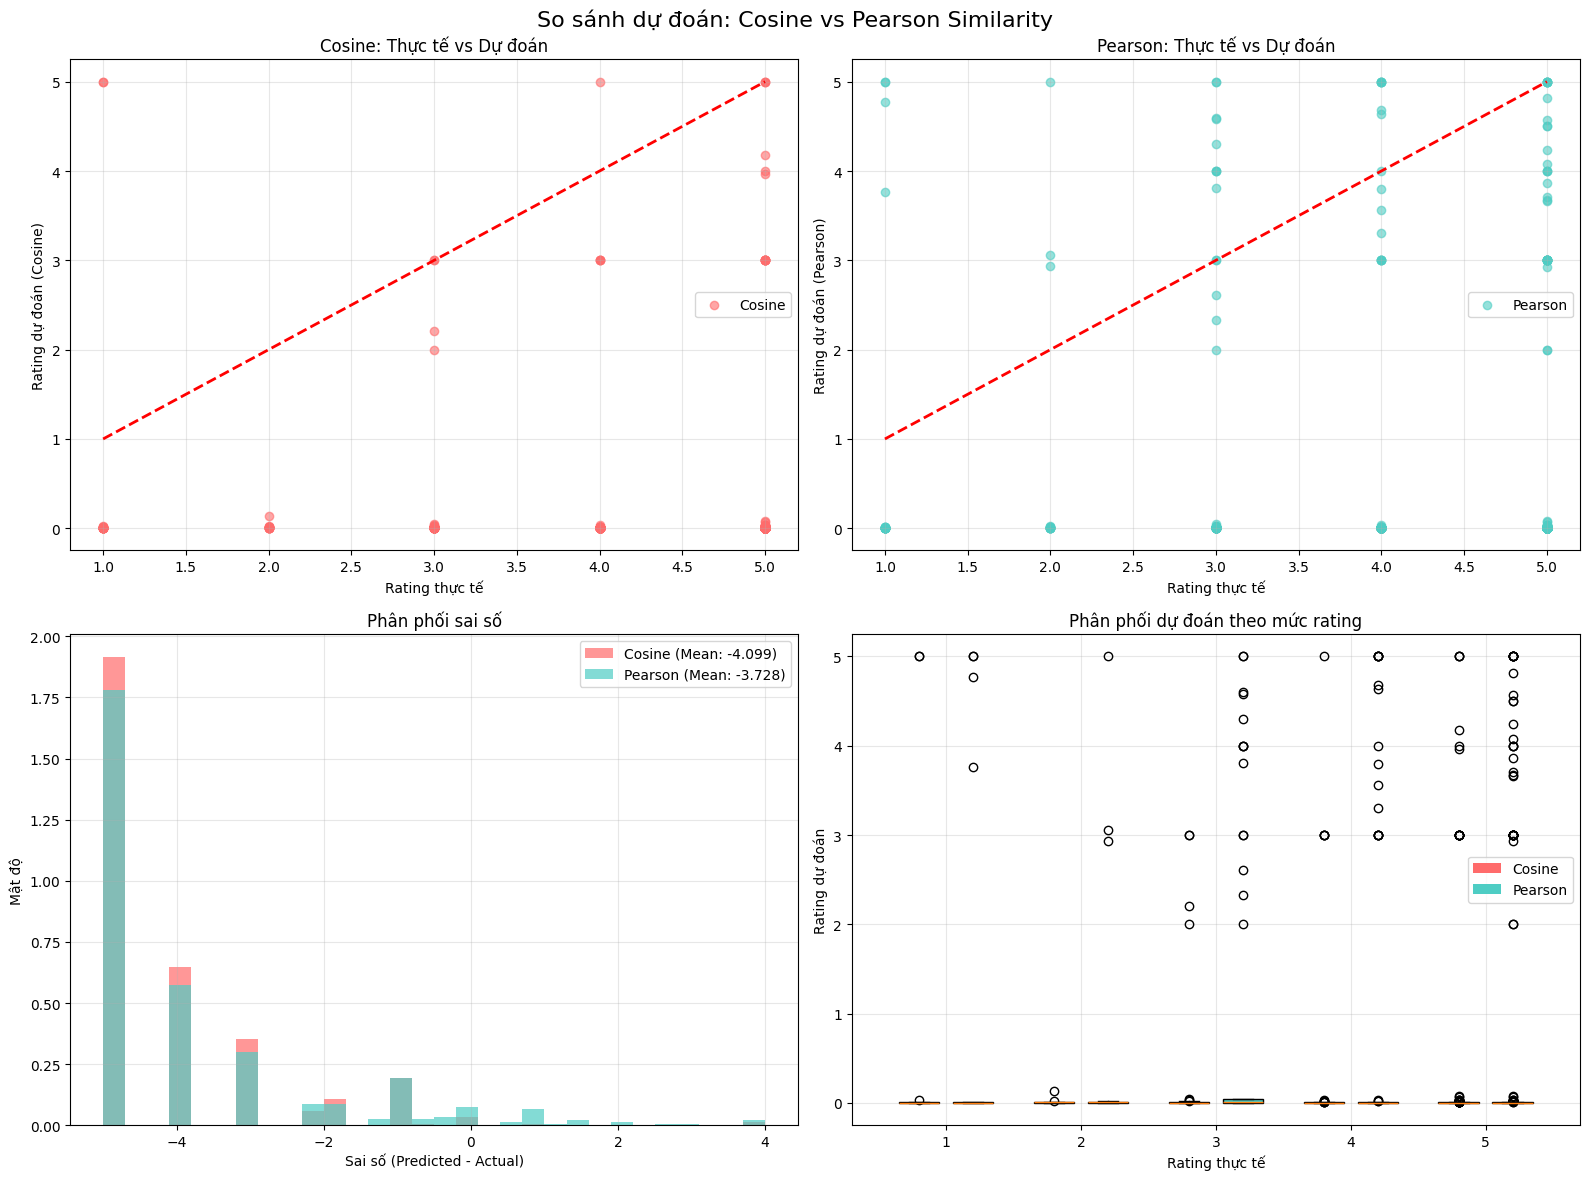


SO SÁNH CHI TIẾT: ITEM-ITEM COLLABORATIVE FILTERING
Chỉ số     Cosine       Pearson      Tốt hơn         Cải thiện (%)  
--------------------------------------------------------------------------------
MSE        18.683026    17.332426    Pearson         7.23           
RMSE       4.322387     4.163223     Pearson         3.68           
MAE        4.135250     3.881066     Pearson         6.15           
NMAE       1.033812     0.970267     Pearson         6.15           

TỔNG KẾT:
Cosine thắng: 0/4 chỉ số
Pearson thắng: 4/4 chỉ số
🏆 PEARSON SIMILARITY THẮNG TỔNG THỂ!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

# Đặt font cho matplotlib để hiển thị tiếng Việt
plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['figure.figsize'] = (12, 8)

class ItemItemCollaborativeFiltering:
    def __init__(self, similarity_metric='cosine', similarity_threshold=0.1):
        """
        similarity_metric: 'cosine' hoặc 'pearson'
        """
        self.similarity_metric = similarity_metric
        self.similarity_threshold = similarity_threshold
        self.item_similarity_matrix = None
        self.user_item_matrix = None
        self.item_means = None
        
    def calculate_pearson_similarity(self, matrix):
        """
        Tính toán Pearson correlation coefficient giữa các item
        """
        n_items = matrix.shape[0]
        similarity_matrix = np.zeros((n_items, n_items))
        
        print("Đang tính Pearson similarity...")
        for i in range(n_items):
            if i % 50 == 0:
                print(f"Đã xử lý: {i}/{n_items} items ({i/n_items*100:.1f}%)")
                
            for j in range(i, n_items):
                if i == j:
                    similarity_matrix[i, j] = 1.0
                else:
                    # Lấy ratings của 2 items
                    item_i_ratings = matrix.iloc[i].values
                    item_j_ratings = matrix.iloc[j].values
                    
                    # Chỉ tính correlation cho users đã rating cả 2 items
                    mask = (item_i_ratings != 0) & (item_j_ratings != 0)
                    
                    if np.sum(mask) < 2:  # Cần ít nhất 2 users chung
                        similarity_matrix[i, j] = 0
                        similarity_matrix[j, i] = 0
                    else:
                        ratings_i = item_i_ratings[mask]
                        ratings_j = item_j_ratings[mask]
                        
                        # Tính Pearson correlation
                        if np.std(ratings_i) == 0 or np.std(ratings_j) == 0:
                            corr = 0
                        else:
                            corr, _ = pearsonr(ratings_i, ratings_j)
                            if np.isnan(corr):
                                corr = 0
                        
                        similarity_matrix[i, j] = corr
                        similarity_matrix[j, i] = corr
        
        return similarity_matrix
        
    def fit(self, training_df):
        """
        Huấn luyện mô hình Item-Item Collaborative Filtering
        """
        print(f"Đang xây dựng mô hình với {self.similarity_metric} similarity...")
        
        # Tạo ma trận user-item từ dữ liệu training
        self.user_item_matrix = training_df.pivot_table(
            index='username', 
            columns='id_product', 
            values='rating', 
            fill_value=0
        )
        
        # Tính trung bình rating cho mỗi item
        self.item_means = self.user_item_matrix.mean(axis=0)
        
        print(f"Kích thước ma trận user-item: {self.user_item_matrix.shape}")
        print(f"Đang tính toán ma trận tương đồng {self.similarity_metric}...")
        
        # Chuyển đổi sang ma trận item-user (transpose)
        item_user_matrix = self.user_item_matrix.T
        
        # Chỉ tính cho các item có ít nhất 1 rating
        non_zero_items = (item_user_matrix != 0).sum(axis=1) > 0
        filtered_matrix = item_user_matrix[non_zero_items]
        
        # Tính toán ma trận tương đồng
        if self.similarity_metric == 'cosine':
            similarity_matrix = cosine_similarity(filtered_matrix)
        elif self.similarity_metric == 'pearson':
            similarity_matrix = self.calculate_pearson_similarity(filtered_matrix)
        else:
            raise ValueError("similarity_metric phải là 'cosine' hoặc 'pearson'")
        
        # Tạo DataFrame cho ma trận tương đồng
        item_indices = filtered_matrix.index
        self.item_similarity_matrix = pd.DataFrame(
            similarity_matrix,
            index=item_indices,
            columns=item_indices
        )
        
        print(f"Hoàn thành! Ma trận tương đồng có kích thước: {self.item_similarity_matrix.shape}")
        
    def predict_rating(self, username, item_id, k=10):
        """
        Dự đoán rating cho một cặp user-item
        """
        if username not in self.user_item_matrix.index:
            return self.item_means.get(item_id, 3.0)
            
        if item_id not in self.user_item_matrix.columns:
            return 3.0
            
        # Lấy các item mà user đã rating
        user_ratings = self.user_item_matrix.loc[username]
        rated_items = user_ratings[user_ratings > 0].index.tolist()
        
        if not rated_items:
            return self.item_means.get(item_id, 3.0)
            
        # Tìm k item tương đồng nhất với item_id
        if item_id not in self.item_similarity_matrix.index:
            return self.item_means.get(item_id, 3.0)
            
        similarities = []
        for rated_item in rated_items:
            if rated_item in self.item_similarity_matrix.columns:
                sim = self.item_similarity_matrix.loc[item_id, rated_item]
                if sim > self.similarity_threshold:
                    similarities.append((rated_item, sim, user_ratings[rated_item]))
        
        if not similarities:
            return self.item_means.get(item_id, 3.0)
            
        # Sắp xếp theo độ tương đồng và lấy top k
        similarities.sort(key=lambda x: x[1], reverse=True)
        top_k_similarities = similarities[:k]
        
        # Tính toán predicted rating
        weighted_sum = sum(sim * rating for _, sim, rating in top_k_similarities)
        similarity_sum = sum(sim for _, sim, _ in top_k_similarities)
        
        if similarity_sum == 0:
            return self.item_means.get(item_id, 3.0)
            
        predicted_rating = weighted_sum / similarity_sum
        
        # Đảm bảo rating nằm trong khoảng [1, 5]
        return max(1, min(5, predicted_rating))
    
    def predict_batch(self, test_df):
        """
        Dự đoán rating cho toàn bộ test set
        """
        predictions = []
        total = len(test_df)
        
        print(f"Đang dự đoán {self.similarity_metric} cho {total} mẫu test...")
        
        for idx, row in test_df.iterrows():
            if idx % 50 == 0:
                print(f"Đã xử lý: {idx}/{total} ({idx/total*100:.1f}%)")
                
            predicted_rating = self.predict_rating(row['username'], row['id_product'])
            predictions.append(predicted_rating)
            
        print(f"Hoàn thành dự đoán {self.similarity_metric}!")
        return np.array(predictions)

def calculate_metrics(y_true, y_pred):
    """
    Tính toán các chỉ số đánh giá
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    # NMAE: Normalized MAE
    rating_range = np.max(y_true) - np.min(y_true)
    nmae = mae / rating_range if rating_range > 0 else 0
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'NMAE': nmae
    }

def plot_comparison_metrics(cosine_metrics, pearson_metrics):
    """
    Vẽ biểu đồ so sánh giữa Cosine và Pearson
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('So sánh Item-Item CF: Cosine vs Pearson Similarity', fontsize=16, fontweight='bold')
    
    metrics_names = list(cosine_metrics.keys())
    cosine_values = list(cosine_metrics.values())
    pearson_values = list(pearson_metrics.values())
    
    x = np.arange(len(metrics_names))
    width = 0.35
    
    # Biểu đồ cột so sánh tất cả metrics
    bars1 = ax1.bar(x - width/2, cosine_values, width, label='Cosine', 
                    color='#FF6B6B', alpha=0.8)
    bars2 = ax1.bar(x + width/2, pearson_values, width, label='Pearson', 
                    color='#4ECDC4', alpha=0.8)
    
    ax1.set_xlabel('Chỉ số đánh giá')
    ax1.set_ylabel('Giá trị')
    ax1.set_title('So sánh tất cả chỉ số đánh giá')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics_names)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Thêm giá trị lên trên mỗi cột
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    # Biểu đồ radar so sánh
    angles = np.linspace(0, 2*np.pi, len(metrics_names), endpoint=False).tolist()
    angles += angles[:1]
    
    # Normalize để vẽ radar
    max_val = max(max(cosine_values), max(pearson_values))
    cosine_normalized = [v/max_val for v in cosine_values] + [cosine_values[0]/max_val]
    pearson_normalized = [v/max_val for v in pearson_values] + [pearson_values[0]/max_val]
    
    ax2 = plt.subplot(2, 2, 2, projection='polar')
    ax2.plot(angles, cosine_normalized, 'o-', linewidth=2, label='Cosine', color='#FF6B6B')
    ax2.fill(angles, cosine_normalized, alpha=0.25, color='#FF6B6B')
    ax2.plot(angles, pearson_normalized, 'o-', linewidth=2, label='Pearson', color='#4ECDC4')
    ax2.fill(angles, pearson_normalized, alpha=0.25, color='#4ECDC4')
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(metrics_names)
    ax2.set_title('Radar Chart (Normalized)')
    ax2.legend()
    
    # Biểu đồ so sánh từng metric riêng lẻ
    metric_comparison = pd.DataFrame({
        'Cosine': cosine_values,
        'Pearson': pearson_values
    }, index=metrics_names)
    
    metric_comparison.plot(kind='bar', ax=ax3, color=['#FF6B6B', '#4ECDC4'])
    ax3.set_title('So sánh chi tiết từng chỉ số')
    ax3.set_ylabel('Giá trị')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)
    
    # Biểu đồ tỷ lệ cải thiện
    improvement = []
    for i, metric in enumerate(metrics_names):
        # Với MSE, RMSE, MAE, NMAE thì giá trị thấp hơn là tốt hơn
        if cosine_values[i] > pearson_values[i]:
            improve = (cosine_values[i] - pearson_values[i]) / cosine_values[i] * 100
            improvement.append(('Pearson', improve))
        else:
            improve = (pearson_values[i] - cosine_values[i]) / pearson_values[i] * 100
            improvement.append(('Cosine', improve))
    
    colors = ['#4ECDC4' if imp[0] == 'Pearson' else '#FF6B6B' for imp in improvement]
    bars = ax4.bar(metrics_names, [imp[1] for imp in improvement], color=colors)
    ax4.set_title('Tỷ lệ cải thiện (%)')
    ax4.set_ylabel('Phần trăm cải thiện')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3)
    
    # Thêm nhãn cho biểu đồ cải thiện
    for i, (bar, imp) in enumerate(zip(bars, improvement)):
        ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{imp[0]}\n+{imp[1]:.2f}%', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

def plot_prediction_comparison(y_true, y_pred_cosine, y_pred_pearson):
    """
    Vẽ biểu đồ so sánh dự đoán của Cosine và Pearson
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('So sánh dự đoán: Cosine vs Pearson Similarity', fontsize=16)
    
    # Scatter plot: Actual vs Predicted cho Cosine
    ax1.scatter(y_true, y_pred_cosine, alpha=0.6, color='#FF6B6B', label='Cosine')
    ax1.plot([1, 5], [1, 5], 'r--', lw=2)
    ax1.set_xlabel('Rating thực tế')
    ax1.set_ylabel('Rating dự đoán (Cosine)')
    ax1.set_title('Cosine: Thực tế vs Dự đoán')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Scatter plot: Actual vs Predicted cho Pearson
    ax2.scatter(y_true, y_pred_pearson, alpha=0.6, color='#4ECDC4', label='Pearson')
    ax2.plot([1, 5], [1, 5], 'r--', lw=2)
    ax2.set_xlabel('Rating thực tế')
    ax2.set_ylabel('Rating dự đoán (Pearson)')
    ax2.set_title('Pearson: Thực tế vs Dự đoán')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Histogram so sánh errors
    errors_cosine = y_pred_cosine - y_true
    errors_pearson = y_pred_pearson - y_true
    
    ax3.hist(errors_cosine, bins=30, alpha=0.7, color='#FF6B6B', 
             label=f'Cosine (Mean: {np.mean(errors_cosine):.3f})', density=True)
    ax3.hist(errors_pearson, bins=30, alpha=0.7, color='#4ECDC4', 
             label=f'Pearson (Mean: {np.mean(errors_pearson):.3f})', density=True)
    ax3.set_xlabel('Sai số (Predicted - Actual)')
    ax3.set_ylabel('Mật độ')
    ax3.set_title('Phân phối sai số')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Box plot so sánh theo từng mức rating
    rating_levels = sorted(np.unique(y_true))
    cosine_by_rating = [y_pred_cosine[y_true == rating] for rating in rating_levels]
    pearson_by_rating = [y_pred_pearson[y_true == rating] for rating in rating_levels]
    
    positions_cosine = [i - 0.2 for i in range(len(rating_levels))]
    positions_pearson = [i + 0.2 for i in range(len(rating_levels))]
    
    bp1 = ax4.boxplot(cosine_by_rating, positions=positions_cosine, widths=0.3, 
                      patch_artist=True, boxprops=dict(facecolor='#FF6B6B'))
    bp2 = ax4.boxplot(pearson_by_rating, positions=positions_pearson, widths=0.3, 
                      patch_artist=True, boxprops=dict(facecolor='#4ECDC4'))
    
    ax4.set_xlabel('Rating thực tế')
    ax4.set_ylabel('Rating dự đoán')
    ax4.set_title('Phân phối dự đoán theo mức rating')
    ax4.set_xticks(range(len(rating_levels)))
    ax4.set_xticklabels(rating_levels)
    ax4.grid(True, alpha=0.3)
    
    # Tạo legend cho box plot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#FF6B6B', label='Cosine'),
                      Patch(facecolor='#4ECDC4', label='Pearson')]
    ax4.legend(handles=legend_elements)
    
    plt.tight_layout()
    plt.show()

def print_detailed_comparison(cosine_metrics, pearson_metrics):
    """
    In bảng so sánh chi tiết
    """
    print("\n" + "="*80)
    print("SO SÁNH CHI TIẾT: ITEM-ITEM COLLABORATIVE FILTERING")
    print("="*80)
    print(f"{'Chỉ số':<10} {'Cosine':<12} {'Pearson':<12} {'Tốt hơn':<15} {'Cải thiện (%)':<15}")
    print("-"*80)
    
    for metric in cosine_metrics.keys():
        cosine_val = cosine_metrics[metric]
        pearson_val = pearson_metrics[metric]
        
        if cosine_val < pearson_val:
            better = "Cosine"
            improvement = (pearson_val - cosine_val) / pearson_val * 100
        else:
            better = "Pearson"
            improvement = (cosine_val - pearson_val) / cosine_val * 100
            
        print(f"{metric:<10} {cosine_val:<12.6f} {pearson_val:<12.6f} {better:<15} {improvement:<15.2f}")
    
    print("="*80)
    
    # Tính overall winner
    cosine_wins = sum(1 for metric in cosine_metrics.keys() 
                     if cosine_metrics[metric] < pearson_metrics[metric])
    pearson_wins = len(cosine_metrics) - cosine_wins
    
    print(f"\nTỔNG KẾT:")
    print(f"Cosine thắng: {cosine_wins}/{len(cosine_metrics)} chỉ số")
    print(f"Pearson thắng: {pearson_wins}/{len(cosine_metrics)} chỉ số")
    
    if cosine_wins > pearson_wins:
        print("🏆 COSINE SIMILARITY THẮNG TỔNG THỂ!")
    elif pearson_wins > cosine_wins:
        print("🏆 PEARSON SIMILARITY THẮNG TỔNG THỂ!")
    else:
        print("🤝 HOÀ NHAU!")

def run_item_cf_comparison(training_df, testing_df_sampled):
    """
    Chạy so sánh giữa Cosine và Pearson Item-Item CF
    """
    # Huấn luyện mô hình Cosine
    print("="*60)
    print("BƯỚC 1: HUẤN LUYỆN MÔ HÌNH COSINE SIMILARITY")
    print("="*60)
    model_cosine = ItemItemCollaborativeFiltering(similarity_metric='cosine', similarity_threshold=0.1)
    model_cosine.fit(training_df)
    
    # Huấn luyện mô hình Pearson
    print("\n" + "="*60)
    print("BƯỚC 2: HUẤN LUYỆN MÔ HÌNH PEARSON SIMILARITY")
    print("="*60)
    model_pearson = ItemItemCollaborativeFiltering(similarity_metric='pearson', similarity_threshold=0.1)
    model_pearson.fit(training_df)
    
    # Dự đoán
    print("\n" + "="*60)
    print("BƯỚC 3: DỰ ĐOÁN VÀ ĐÁNH GIÁ")
    print("="*60)
    
    y_true = testing_df_sampled['rating'].values
    y_pred_cosine = model_cosine.predict_batch(testing_df_sampled)
    y_pred_pearson = model_pearson.predict_batch(testing_df_sampled)
    
    # Tính metrics
    cosine_metrics = calculate_metrics(y_true, y_pred_cosine)
    pearson_metrics = calculate_metrics(y_true, y_pred_pearson)
    
    # Vẽ biểu đồ so sánh
    plot_comparison_metrics(cosine_metrics, pearson_metrics)
    plot_prediction_comparison(y_true, y_pred_cosine, y_pred_pearson)
    
    # In kết quả chi tiết
    print_detailed_comparison(cosine_metrics, pearson_metrics)
    
    return {
        'cosine_model': model_cosine,
        'pearson_model': model_pearson,
        'cosine_metrics': cosine_metrics,
        'pearson_metrics': pearson_metrics,
        'predictions': {
            'y_true': y_true,
            'y_pred_cosine': y_pred_cosine,
            'y_pred_pearson': y_pred_pearson
        }
    }

# Ví dụ sử dụng:
results = run_item_cf_comparison(training_df, testing_df_sampled)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Assume the dataframes from your code are available: training_df, testing_df_sampled
# Expected columns: ['id_product', 'username', 'rating']

def item_item_collaborative_filtering(training_df, testing_df, k_values):
    results = {'MSE': [], 'RMSE': [], 'MAE': [], 'NMAE': []}
    
    # Create item-user matrix
    item_user_matrix = training_df.pivot_table(
        index='id_product', 
        columns='username', 
        values='rating'
    ).fillna(0)
    
    # Calculate item-item similarity using cosine similarity
    item_similarity = cosine_similarity(item_user_matrix)
    item_similarity_df = pd.DataFrame(
        item_similarity,
        index=item_user_matrix.index,
        columns=item_user_matrix.index
    )
    
    # Function to predict rating for a specific user-item pair
    def predict_rating(product_id, username, k):
        if product_id not in item_user_matrix.index:
            return training_df['rating'].mean()
        
        # Get k most similar items
        similar_items = item_similarity_df[product_id].sort_values(ascending=False)[1:k+1]
        
        # Get ratings from this user for similar items
        user_ratings = item_user_matrix.loc[similar_items.index, username]
        
        # Get similarity scores for these items
        sim_scores = similar_items.values
        
        # Calculate weighted average rating
        if sim_scores.sum() > 0:
            return np.dot(user_ratings, sim_scores) / sim_scores.sum()
        else:
            return training_df['rating'].mean()
    
    # Evaluate for different k values
    for k in k_values:
        predictions = []
        actual_ratings = []
        
        for _, row in testing_df.iterrows():
            pred = predict_rating(row['id_product'], row['username'], k)
            predictions.append(pred)
            actual_ratings.append(row['rating'])
        
        predictions = np.array(predictions)
        actual_ratings = np.array(actual_ratings)
        
        # MSE
        mse = np.mean((predictions - actual_ratings) ** 2)
        results['MSE'].append(mse)
        
        # RMSE
        rmse = np.sqrt(mse)
        results['RMSE'].append(rmse)
        
        # MAE
        mae = np.mean(np.abs(predictions - actual_ratings))
        results['MAE'].append(mae)
        
        # NMAE (normalized by rating range)
        rating_range = training_df['rating'].max() - training_df['rating'].min()
        nmae = mae / rating_range if rating_range > 0 else mae
        results['NMAE'].append(nmae)
    
    return results, k_values

# Run the collaborative filtering with different k values
k_values = range(5, 155, 5)  # Test k from 5 to 150 with step 5
results, k_values = item_item_collaborative_filtering(training_df, testing_df_sampled, k_values)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, results['MSE'], label='Item-Item Cosine', color='green')
# Add other similarity metrics (e.g., Pearson) as needed; here we focus on cosine for simplicity
plt.xlabel('Number of near neighbors')
plt.ylabel('MSE')
plt.title('(a) MSE')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig('mse_vs_neighbors.png')
plt.close()

# Additional plots for RMSE, MAE, NMAE (similar structure)
metrics = ['RMSE', 'MAE', 'NMAE']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, results[metric], label='Item-Item Cosine', color='green')
    plt.xlabel('Number of near neighbors')
    plt.ylabel(metric)
    plt.title(f'(a) {metric}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{metric.lower()}_vs_neighbors.png')
    plt.close()

print("Plots saved as mse_vs_neighbors.png, rmse_vs_neighbors.png, mae_vs_neighbors.png, nmae_vs_neighbors.png")

KeyError: 'user_id'